In [2]:

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json
import sys
import glob
print(Path.cwd())
# Add lib to path for importing FCN3Network
sys.path.insert(0, str(Path.cwd().parent.parent / "lib"))

print("Libraries imported successfully!")

/home/akiva/FCNX-Ensembling/milestones/activation_generic_erf_mf_scaling_convergence
Libraries imported successfully!


In [25]:
model_dir = Path("/home/akiva/FCNX-Ensembling/milestones/activation_generic_erf_mf_scaling_convergence/P_scan_KAPPA0.1_FINALIZED/d150_P1418_N1600_chi1600_kappa0.1/")
model_path = model_dir / "model.pt"
config_path = model_dir / "config.json"

In [26]:
str(model_dir.parent)

'/home/akiva/FCNX-Ensembling/milestones/activation_generic_erf_mf_scaling_convergence/P_scan_KAPPA0.1_FINALIZED'

In [27]:
config_files = glob.glob(str(model_dir.parent) + '/**/config.json', recursive=True)
# Open the first config file to check its contents
with open(config_files[0], 'r') as f:
    config_data = json.load(f)
print(json.dumps(config_data, indent=4))

{
    "d": 150,
    "P": 1541,
    "N": 1600,
    "kappa": 0.1,
    "lr": 1.1111111111111112e-05,
    "epochs": 700000,
    "chi": 10,
    "seed": 2,
    "ens": 10,
    "current_epoch": 700000
}


In [43]:
# Loop through the config files and for each one, load the corresponding model, extract the seed, and generate a test dataset
# of 5000 samples. Then compute learnability metric for he3 via
# h3_component = y_pred_np[sort_idx, :].mean(axis=1) - (y_pred_np[sort_idx, :].mean(
#     axis=1) @ X_test_np[sort_idx, 0] / X_test_np.shape[0]) * X_test_np[sort_idx, 0]
# he3 = (X_test_np[sort_idx, 0]**3 - 3 * X_test_np[sort_idx, 0]) / 6**0.5
# y_k = (he3 @ y_pred_np[sort_idx, :].mean(axis=1) / y_pred_np.shape[0])
# he3 @ h3_component / X_test_np.shape[0] / y_k

from torch import device

from torch.cuda import device

from FCN3Network import FCN3NetworkActivationGeneric


learnability_metrics = []
# Use only torch for computations on GPU
for config_file in config_files:
    with open(config_file, 'r') as f:
        config_data = json.load(f)
    seed = config_data['seed']
    P = config_data['P']
    n1 = config_data['N']
    n2 = config_data['N']
    d = config_data['d']
    ens = config_data['ens']
    device=torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
    print(f"Processing config file: {config_file}, seed: {seed}")
    # Load the corresponding model
    model_path = Path(config_file).parent / "model.pt"
    model_state = torch.load(model_path, map_location='cpu')
    # Generate a test dataset of 5000 samples
    torch.manual_seed(seed + 1)  # Use a different seed for test data generation
    X_test = torch.randn(10000, d, device=device)
    y_test = (X_test**3 - 3 * X_test) / 6**0.5
    # Get model predictions
    model = FCN3NetworkActivationGeneric(
    d=d, n1=n1, n2=n2, P=P, ens=ens, activation="erf",
    weight_initialization_variance=(1.0/d, 1.0/n1, 1.0/(n1*n2)),
    device=device
    )   
    model.load_state_dict(model_state)
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test)
    # Compute learnability metric for he3
    sort_idx = torch.argsort(X_test[:, 0])
    h3_component = y_pred[sort_idx, :].mean(dim=1) - (y_pred[sort_idx, :].mean(
        dim=1) @ X_test[sort_idx, 0] / X_test.shape[0]) * X_test[sort_idx, 0]
    he3 = (X_test[sort_idx, 0]**3 - 3 * X_test[sort_idx, 0]) / 6**0.5
    train_set = torch.randn(P, d, device=device)
    train_pred = model(train_set)
    he3_train = (train_set[:, 0]**3 - 3 * train_set[:, 0]) / 6**0.5
    he3_train = he3_train / he3_train.norm()
    # he1 = train_set[:,0]/train_set[:,0].norm()
    # y_train = he1 + 0.074 * he3_train
    # y_3_train = (y_train - (y_train @ train_set[:, 0] / train_set.shape[0]) * train_set[:, 0]) @ he3_train / train_set.shape[0]
    y_k = (he3 @ y_pred[sort_idx, :].mean(dim=1) / y_pred.shape[0])
    learnability_metric = (he3 @ h3_component / X_test.shape[0] / y_k).item()
    learnability_metrics.append((P, seed, learnability_metric))
    print(f"Learnability metric for seed {seed}: {learnability_metric}")


Processing config file: /home/akiva/FCNX-Ensembling/milestones/activation_generic_erf_mf_scaling_convergence/P_scan_KAPPA0.1_FINALIZED/d150_P1541_N1600_chi10_kappa0.1/seed2/config.json, seed: 2
Learnability metric for seed 2: 3.285607099533081
Processing config file: /home/akiva/FCNX-Ensembling/milestones/activation_generic_erf_mf_scaling_convergence/P_scan_KAPPA0.1_FINALIZED/d150_P1541_N1600_chi10_kappa0.1/seed7/config.json, seed: 7
Learnability metric for seed 7: -0.4856332540512085
Processing config file: /home/akiva/FCNX-Ensembling/milestones/activation_generic_erf_mf_scaling_convergence/P_scan_KAPPA0.1_FINALIZED/d150_P1541_N1600_chi10_kappa0.1/seed4/config.json, seed: 4
Learnability metric for seed 4: -2.8666257858276367
Processing config file: /home/akiva/FCNX-Ensembling/milestones/activation_generic_erf_mf_scaling_convergence/P_scan_KAPPA0.1_FINALIZED/d150_P1541_N1600_chi10_kappa0.1/seed5/config.json, seed: 5
Learnability metric for seed 5: 0.3033939003944397
Processing config f

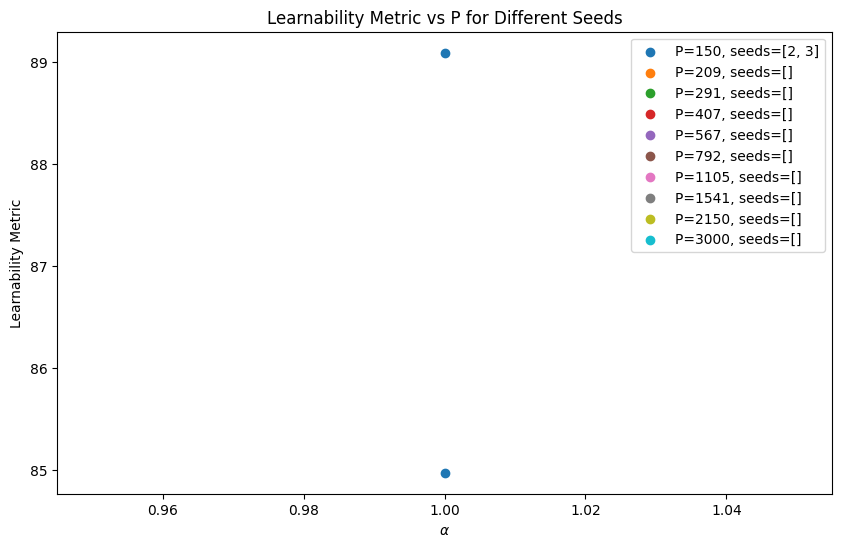

In [42]:
import numpy as np
# Plot learnability metrics per P, i.e. (P, learnability), P independent variable, learnability dependent variable, with different colors for different seeds
plt.figure(figsize=(10, 6))
for P in sorted(set([x[0] for x in learnability_metrics])):
    P_metrics = [x[2] for x in learnability_metrics if x[0] == P and x[2] > 0]
    seeds = [x[1] for x in learnability_metrics if x[0] == P and x[2] > 0]

    plt.scatter([np.log(P)/ np.log(d)]*len(P_metrics), P_metrics, label=f'P={P}, seeds={seeds}')
plt.xlabel('$\\alpha$')
plt.ylabel('Learnability Metric')
plt.title('Learnability Metric vs P for Different Seeds')
plt.legend()
plt.show()